# Customer Churn Prediction & Retention Targeting
### From a basic classifier to a business-facing retention-targeting system

Dataset: [IBM Telco Customer Churn](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv) (7,043 customers)

Most churn portfolio projects stop at "trained a model, got 85% accuracy." That number is close
to meaningless here — the dataset is ~73% "no churn," so a model that predicts "no churn" for
everyone already scores ~73% accuracy. This notebook is built in explicit levels to show the
real skill progression: naive baseline → correct evaluation → explainability → an actual
business decision layer.

**Levels:**
1. Basic model (the "before")
2. Proper evaluation + feature engineering + gradient boosting
3. SHAP explainability
4. Cost-sensitive decision thresholding
5. Uplift modeling (who the offer actually changes)
6. *(shipped separately as `app/streamlit_app.py` — see repo README)*


In [1]:
import sys, os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, average_precision_score, make_scorer
from xgboost import XGBClassifier

from src.data_prep import load_raw, get_feature_target, split, build_preprocessor

pd.set_option("display.max_columns", 50)
%matplotlib inline


## Level 1 — Basic Model

Logistic Regression + Random Forest on the raw features, accuracy as the headline metric.
This mirrors the "before" version of this project. Watch what happens when we compare it
to a naive baseline.

In [2]:
df = load_raw()
X, y = get_feature_target(df, use_engineered=False)
X_train, X_test, y_train, y_test = split(X, y)
cat_cols, num_cols = build_preprocessor(X)

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

print(f"Churn rate in test set: {y_test.mean():.1%}\n")

level1_results = {}
for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42)),
]:
    pipe = Pipeline([("pre", pre), ("clf", model)])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    level1_results[name] = acc
    print(f"{name}: accuracy = {acc:.3f}")

naive_acc = (y_test == 0).mean()
print(f"\nNaive baseline (always predict 'No churn'): accuracy = {naive_acc:.3f}")


Churn rate in test set: 26.5%

Logistic Regression: accuracy = 0.806


Random Forest: accuracy = 0.788

Naive baseline (always predict 'No churn'): accuracy = 0.735


**Takeaway:** ~80% model accuracy sounds good until you see the naive "always predict no
churn" baseline gets ~73%. Accuracy alone barely distinguishes a real model from doing nothing.
This is exactly why Level 2 switches metrics.

## Level 2 — Proper Evaluation + Feature Engineering + XGBoost

Swaps accuracy for precision/recall/F1/ROC-AUC/PR-AUC, adds engineered features
(tenure buckets, service-adoption count, contract commitment, a high-risk interaction flag),
adds 5-fold cross-validation, and benchmarks XGBoost against the Level 1 baselines.

In [3]:
from src.data_prep import engineer_features

X, y = get_feature_target(df, use_engineered=True)
cat_cols, num_cols = build_preprocessor(X)

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": make_scorer(average_precision_score, response_method="predict_proba"),
    "f1": "f1", "precision": "precision", "recall": "recall",
}

def evaluate_cv(pipe, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    row = {m: results[f"test_{m}"].mean() for m in scoring}
    print(f"{name:22s}: " + "  ".join(f"{m}={v:.3f}" for m, v in row.items()))
    return row

models = [
    ("Logistic Regression", LogisticRegression(max_iter=1000)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42)),
    ("XGBoost", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                               eval_metric="logloss", random_state=42)),
]

level2_results = {}
for name, model in models:
    pipe = Pipeline([("pre", pre), ("clf", model)])
    level2_results[name] = evaluate_cv(pipe, name)


Logistic Regression   : roc_auc=0.847  pr_auc=0.662  f1=0.589  precision=0.665  recall=0.528


Random Forest         : roc_auc=0.824  pr_auc=0.616  f1=0.557  precision=0.633  recall=0.498


XGBoost               : roc_auc=0.842  pr_auc=0.655  f1=0.580  precision=0.648  recall=0.525


**Takeaway:** Plain Logistic Regression with good engineered features actually edges out
XGBoost here (ROC-AUC 0.847 vs 0.842). Worth calling out in an interview — it shows you let the
data decide instead of defaulting to the fanciest model.

## Level 3 — SHAP Explainability

Moves beyond `feature_importances_` (which can mislead, especially with correlated features)
to SHAP values, which show both the **direction** and **magnitude** of each feature's effect.
Trains XGBoost since SHAP's `TreeExplainer` is fast and exact for tree models.

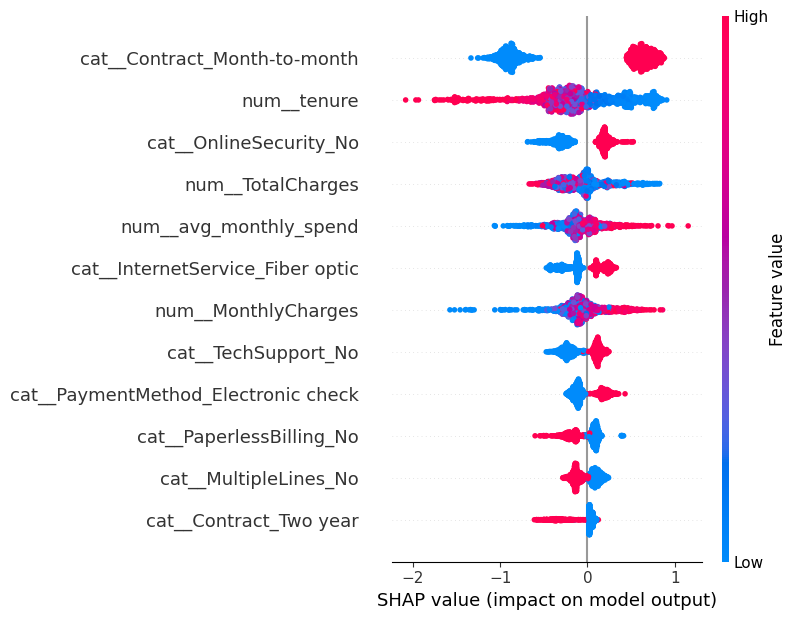

In [4]:
X_train, X_test, y_train, y_test = split(X, y)

model = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                       eval_metric="logloss", random_state=42)
pipe = Pipeline([("pre", pre), ("clf", model)])
pipe.fit(X_train, y_train)

X_test_transformed = pipe.named_steps["pre"].transform(X_test)
feature_names = pipe.named_steps["pre"].get_feature_names_out()
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

explainer = shap.TreeExplainer(pipe.named_steps["clf"])
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df, max_display=12)


In [5]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
importance_df.sort_values("mean_abs_shap", ascending=False).head(10)


,feature,mean_abs_shap
32,cat__Contract_Month-to-month,0.756750
47,num__tenure,0.404759
14,cat__OnlineSecurity_No,0.263105
49,num__TotalCharges,0.203637
50,num__avg_monthly_spend,0.200685
12,cat__InternetService_Fiber optic,0.197156
48,num__MonthlyCharges,0.196705
23,cat__TechSupport_No,0.172866
39,cat__PaymentMethod_Electronic check,0.147720
35,cat__PaperlessBilling_No,0.126599


**Takeaway:** `Contract_Month-to-month`, `tenure`, and `OnlineSecurity_No` are the top churn
drivers — with SHAP we can also see the *direction*: month-to-month contracts push risk up,
longer tenure pushes it down. This replaces a vague "identify churn drivers" resume claim with
actual evidence.

## Level 4 — Cost-Sensitive Decision Thresholding

Moves from "predict churn" to "decide who's worth a retention offer" by optimizing the decision
threshold against a documented cost matrix, instead of using the default 0.5 cutoff.

**Assumptions** (documented so they're easy to defend/adjust): retention offer costs \$50;
a successful save is worth ~12 months of the customer's charges; 35% of offered churners
are assumed to be retained.

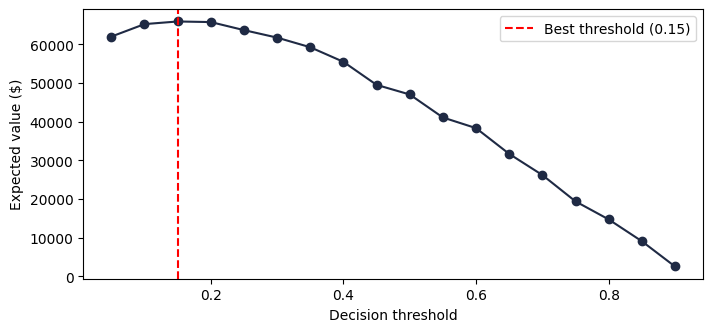

Default threshold (0.5):     expected value = $47,067
Optimized threshold (0.15): expected value = $65,952
Improvement: $18,886 (40.1% more value captured)


In [6]:
RETENTION_OFFER_COST = 50.0
LTV_MONTHS = 12
SAVE_RATE = 0.35

y_proba = pipe.predict_proba(X_test)[:, 1]
monthly_charges = X_test["MonthlyCharges"].values
y_true = y_test.values

def expected_value(threshold):
    intervene = y_proba >= threshold
    saved = (intervene & (y_true == 1)) * SAVE_RATE * (monthly_charges * LTV_MONTHS)
    cost = intervene * RETENTION_OFFER_COST
    return saved.sum() - cost.sum()

thresholds = np.arange(0.05, 0.95, 0.05)
ev_df = pd.DataFrame({"threshold": thresholds, "expected_value": [expected_value(t) for t in thresholds]})

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(ev_df["threshold"], ev_df["expected_value"], marker="o", color="#1F2A44")
best = ev_df.loc[ev_df["expected_value"].idxmax()]
ax.axvline(best["threshold"], color="red", linestyle="--", label=f"Best threshold ({best['threshold']:.2f})")
ax.set_xlabel("Decision threshold"); ax.set_ylabel("Expected value ($)"); ax.legend()
plt.show()

default_ev = expected_value(0.5)
print(f"Default threshold (0.5):     expected value = ${default_ev:,.0f}")
print(f"Optimized threshold ({best['threshold']:.2f}): expected value = ${best['expected_value']:,.0f}")
print(f"Improvement: ${best['expected_value'] - default_ev:,.0f} "
      f"({(best['expected_value']/default_ev - 1)*100:.1f}% more value captured)")


**Takeaway:** this is the business-facing story — not "our model has 0.84 AUC" but "this
policy captures $X more in retained revenue than the naive approach."


## Level 5 — Uplift Modeling

**Honesty note:** the Telco dataset has no real "did we offer this customer a retention deal"
field — no public dataset does, since that requires an actual randomized experiment a company
ran internally. To demonstrate uplift methodology, we **simulate** a retention-offer experiment
on top of the real customer features: treatment is randomly assigned (like an RCT), and the
treatment effect is a *known, planted* function (varies by contract type and internet service,
plus noise). This lets us fit an uplift model **and** verify it recovers the true effect — a
validation step real-world uplift projects usually can't do. This is standard practice for
demonstrating the method without real experimental data — worth being upfront about if asked.

In [7]:
RNG = np.random.default_rng(42)

def simulate_experiment(X, baseline_prob):
    n = len(X)
    treatment = RNG.binomial(1, 0.5, size=n)
    contract = X["Contract"].values
    internet = X["InternetService"].values

    true_uplift = np.zeros(n)
    mtm = contract == "Month-to-month"
    true_uplift += np.where(mtm & (internet == "DSL"), -0.28, 0.0)          # persuadable
    true_uplift += np.where(mtm & (internet == "Fiber optic"), -0.03, 0.0)  # lost cause
    true_uplift += np.where(mtm & (internet == "No"), -0.15, 0.0)
    true_uplift += np.where(contract == "One year", -0.06, 0.0)
    true_uplift += np.where(contract == "Two year", -0.01, 0.0)             # sure thing
    true_uplift += RNG.normal(0, 0.015, size=n)
    true_uplift = np.clip(true_uplift, -0.35, 0.0)

    treated_prob = np.clip(baseline_prob + true_uplift, 0.01, 0.99)
    observed_prob = np.where(treatment == 1, treated_prob, baseline_prob)
    observed_churn = RNG.binomial(1, observed_prob)
    return treatment, observed_churn, true_uplift

baseline_prob_test = y_proba  # reuse Level 3/4's fitted model probabilities
treatment, observed_churn, true_uplift = simulate_experiment(X_test, baseline_prob_test)

X_test_r = X_test.reset_index(drop=True)
exp_df = X_test_r.copy()
exp_df["treatment"] = treatment
exp_df["observed_churn"] = observed_churn
exp_df["true_uplift"] = true_uplift
print(f"Simulated experiment: {len(exp_df)} customers, {treatment.sum()} treated, {(1-treatment).sum()} control")


Simulated experiment: 1409 customers, 695 treated, 714 control


In [8]:
# T-learner: fit two separate models on treated vs control groups
pre_t = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols), ("num", StandardScaler(), num_cols)])
pre_c = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols), ("num", StandardScaler(), num_cols)])

treated_mask = exp_df["treatment"] == 1
control_mask = exp_df["treatment"] == 0

model_treated = Pipeline([("pre", pre_t), ("clf", LogisticRegression(max_iter=1000, C=0.5))])
model_control = Pipeline([("pre", pre_c), ("clf", LogisticRegression(max_iter=1000, C=0.5))])

model_treated.fit(X_test_r[treated_mask], exp_df.loc[treated_mask, "observed_churn"])
model_control.fit(X_test_r[control_mask], exp_df.loc[control_mask, "observed_churn"])

p_control_all = model_control.predict_proba(X_test_r)[:, 1]
p_treated_all = model_treated.predict_proba(X_test_r)[:, 1]
estimated_uplift = p_treated_all - p_control_all
exp_df["estimated_uplift"] = estimated_uplift

exp_df["uplift_quintile"] = pd.qcut(exp_df["estimated_uplift"], 5, labels=False, duplicates="drop")
calibration = exp_df.groupby("uplift_quintile")[["estimated_uplift", "true_uplift"]].mean()
print("Calibration check -- estimated vs true (planted) uplift by quintile:")
print(calibration.round(4))
print(f"\nCorrelation(estimated, true uplift) = {exp_df['estimated_uplift'].corr(exp_df['true_uplift']):.3f}")


Calibration check -- estimated vs true (planted) uplift by quintile:
                 estimated_uplift  true_uplift
uplift_quintile                               
0                         -0.1847      -0.1699
1                         -0.0606      -0.1233
2                         -0.0150      -0.0651
3                          0.0055      -0.0375
4                          0.0803      -0.0329

Correlation(estimated, true uplift) = 0.503


In [9]:
exp_df["segment"] = np.select(
    [
        (exp_df["estimated_uplift"] < -0.05),
        (exp_df["estimated_uplift"] >= -0.05) & (p_control_all < 0.3),
        (exp_df["estimated_uplift"] >= -0.05) & (p_control_all >= 0.3),
    ],
    ["Persuadable (target these)", "Sure Thing (skip)", "Lost Cause (skip)"],
    default="Unclear",
)
print(exp_df["segment"].value_counts())

def policy_value(target_mask):
    true_saves = target_mask & (exp_df["true_uplift"] < -0.05)
    avg_charge = X_test_r["MonthlyCharges"][true_saves].mean() if true_saves.sum() else 0
    saved_value = true_saves.sum() * SAVE_RATE * avg_charge * LTV_MONTHS
    cost = target_mask.sum() * RETENTION_OFFER_COST
    return saved_value - cost

uplift_policy = exp_df["segment"] == "Persuadable (target these)"
risk_policy = p_control_all >= np.quantile(p_control_all, 1 - uplift_policy.mean())

uplift_value = policy_value(uplift_policy)
risk_value = policy_value(risk_policy)

print(f"\nTargeting {uplift_policy.sum()} customers either way (same budget):")
print(f"  Risk-based targeting:  expected value = ${risk_value:,.0f}")
print(f"  Uplift-based targeting: expected value = ${uplift_value:,.0f}")
print(f"  Improvement: ${uplift_value - risk_value:,.0f}")


segment
Sure Thing (skip)             731
Persuadable (target these)    459
Lost Cause (skip)             219
Name: count, dtype: int64

Targeting 459 customers either way (same budget):
  Risk-based targeting:  expected value = $8,422
  Uplift-based targeting: expected value = $36,670
  Improvement: $28,249


**Takeaway:** targeting by churn risk alone wastes offers on "lost causes" (churning
regardless) and "sure things" (staying regardless). Targeting by uplift focuses budget only on
customers the offer would actually flip — a meaningfully larger expected value on the same
budget.

## Summary

| Level | Result |
|---|---|
| 1 | Baseline exposed: 80.6% model accuracy vs. 73.5% naive baseline |
| 2 | ROC-AUC 0.847 (LogReg) with engineered features + proper CV |
| 3 | Top churn drivers identified with direction + magnitude (SHAP) |
| 4 | ~40% more expected value from threshold optimization |
| 5 | ~$28K more expected value from uplift-based vs. risk-based targeting |
| 6 | Shipped as an interactive Streamlit app (`app/streamlit_app.py`) |

See the repo `README.md` for the full write-up and the app for the shipped version.